# 04 — Model Training & Interpretation

Train and evaluate 5 models on the clean 209-feature dataset:

| # | Model | Approach |
|---|---|---|
| 1 | **Logistic Regression** | Classical baseline, needs scaling |
| 2 | **Random Forest** | Stable ensemble, needs scaling |
| 3 | **LightGBM** | SOTA gradient boosting |
| 4 | **CatBoost** | SOTA gradient boosting |
| 5 | **EBM** | Interpretable boosting (InterpretML) |

**Evaluation:** Stratified 5-Fold CV, OOF predictions, primary metric = AUC-ROC  
**Class imbalance:** handled per-model (`scale_pos_weight`, `class_weight`, `auto_class_weights`)  
**Interpretation:** Feature importances, LogReg coefficients, SHAP (LightGBM), EBM global explanations

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
from pathlib import Path
from sklearn.base import clone

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src import config
from src.train import (
    load_data,
    get_models,
    cross_validate_model,
    train_final_model,
    save_model,
    load_model,
    plot_roc_curves,
    plot_pr_curves,
    plot_feature_importance,
    plot_cv_score_distribution,
    plot_metrics_comparison,
    plot_fold_heatmap,
    plot_metrics_radar,
    build_comparison_table,
)

print('Ready.')

Ready.


## 1. Load Data

In [2]:
X, y = load_data()

SCALE_POS_WEIGHT = (y == 0).sum() / (y == 1).sum()
print(f'\nscale_pos_weight = {SCALE_POS_WEIGHT:.4f}')
print(f'Features: {X.columns.tolist()[:5]} ... ({X.shape[1]} total)')

Loaded: 307,511 rows × 209 features
Default rate: 8.07%  |  scale_pos_weight: 11.3872

scale_pos_weight = 11.3872
Features: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE'] ... (209 total)


## 2. Define Models

In [3]:
models = get_models(
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=config.RANDOM_SEED,
)

for name, model in models.items():
    print(f'  {name:10s} → {type(model).__name__}')

  logreg     → LogisticRegression
  rf         → RandomForestClassifier
  lgbm       → LGBMClassifier
  catboost   → CatBoostClassifier
  ebm        → ExplainableBoostingClassifier


## 3. Cross-Validation

**Stratified 5-Fold CV** with out-of-fold (OOF) predictions.  
- LogReg & RF: `StandardScaler` applied per fold (fit on train only)  
- LightGBM / CatBoost / EBM: no scaling needed  

> ⚠️ **Slow cell** — expected runtime:  
> LogReg ~3 min · RF ~15 min · LightGBM ~10 min · CatBoost ~20 min · EBM ~30 min

In [4]:
results = {}

for name, model in models.items():
    print(f'\n── {name.upper()} ──')
    results[name] = cross_validate_model(
        model, X, y,
        model_name=name,
        n_splits=5,
        random_state=config.RANDOM_SEED,
    )


── LOGREG ──
  Fold 1: AUC=0.7645  F1=0.2768  Prec=0.1727  Rec=0.6977  Acc=0.7057
  Fold 2: AUC=0.7740  F1=0.2785  Prec=0.1733  Rec=0.7082  Acc=0.7037
  Fold 3: AUC=0.7732  F1=0.2767  Prec=0.1720  Rec=0.7069  Acc=0.7016
  Fold 4: AUC=0.7753  F1=0.2793  Prec=0.1741  Rec=0.7055  Acc=0.7060
  Fold 5: AUC=0.7662  F1=0.2725  Prec=0.1700  Rec=0.6858  Acc=0.7044
  → Mean AUC: 0.7706 ± 0.0044  |  F1: 0.2768  Prec: 0.1724  Rec: 0.7008  Acc: 0.7043

── RF ──
  Fold 1: AUC=0.7572  F1=0.2287  Prec=0.3451  Rec=0.1710  Acc=0.9069
  Fold 2: AUC=0.7597  F1=0.2315  Prec=0.3419  Rec=0.1750  Acc=0.9062
  Fold 3: AUC=0.7539  F1=0.2230  Prec=0.3255  Rec=0.1696  Acc=0.9046
  Fold 4: AUC=0.7617  F1=0.2285  Prec=0.3419  Rec=0.1716  Acc=0.9065
  Fold 5: AUC=0.7532  F1=0.2196  Prec=0.3309  Rec=0.1644  Acc=0.9057
  → Mean AUC: 0.7571 ± 0.0033  |  F1: 0.2263  Prec: 0.3370  Rec: 0.1703  Acc: 0.9060

── LGBM ──
  Fold 1: AUC=0.7736  F1=0.3175  Prec=0.2291  Rec=0.5170  Acc=0.8205
  Fold 2: AUC=0.7826  F1=0.3241  Pr

## 4. Comparison Table

In [5]:
comparison = build_comparison_table(results)

comparison.style \
    .background_gradient(subset=['ROC-AUC (mean)'], cmap='RdYlGn') \
    .background_gradient(subset=['ROC-AUC (std)'],  cmap='RdYlGn_r') \
    .background_gradient(subset=['F1 class-1'],     cmap='RdYlGn') \
    .background_gradient(subset=['F1 weighted'],    cmap='RdYlGn') \
    .background_gradient(subset=['Precision'],      cmap='RdYlGn') \
    .background_gradient(subset=['Recall'],         cmap='RdYlGn') \
    .background_gradient(subset=['Accuracy'],       cmap='RdYlGn') \
    .format(precision=4)

,Model,ROC-AUC (mean),ROC-AUC (std),F1 class-1,F1 weighted,Precision,Recall,Accuracy,AUC Fold 1,AUC Fold 2,AUC Fold 3,AUC Fold 4,AUC Fold 5
0,CATBOOST,0.7858,0.0034,0.3027,0.8043,0.1956,0.6699,0.7509,0.7834,0.7898,0.7840,0.7900,0.7820
1,EBM,0.7853,0.0038,0.0879,0.8879,0.5467,0.0478,0.9199,0.7802,0.7912,0.7842,0.7879,0.7833
2,LGBM,0.7782,0.0033,0.3213,0.8508,0.2319,0.5231,0.8216,0.7736,0.7826,0.7769,0.7814,0.7767
3,LOGREG,0.7706,0.0044,0.2768,0.7708,0.1724,0.7008,0.7043,0.7645,0.7740,0.7732,0.7753,0.7662
4,RF,0.7571,0.0033,0.2263,0.8915,0.3370,0.1703,0.9060,0.7572,0.7597,0.7539,0.7617,0.7532


## 5. ROC Curves

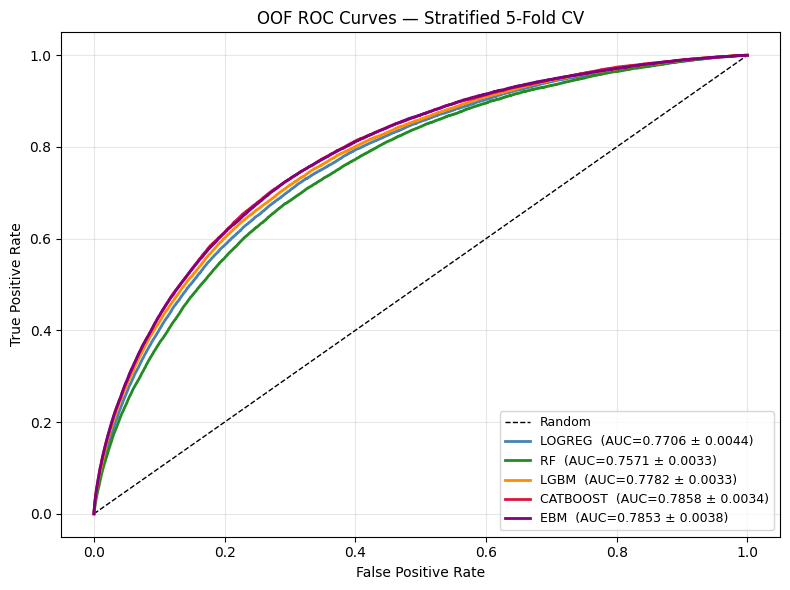

Saved → reports/roc_curves.png


In [6]:
fig = plot_roc_curves(
    results,
    save_path=ROOT / 'reports' / 'roc_curves.png',
)
plt.show()
print('Saved → reports/roc_curves.png')

## 6. CV Score Distribution

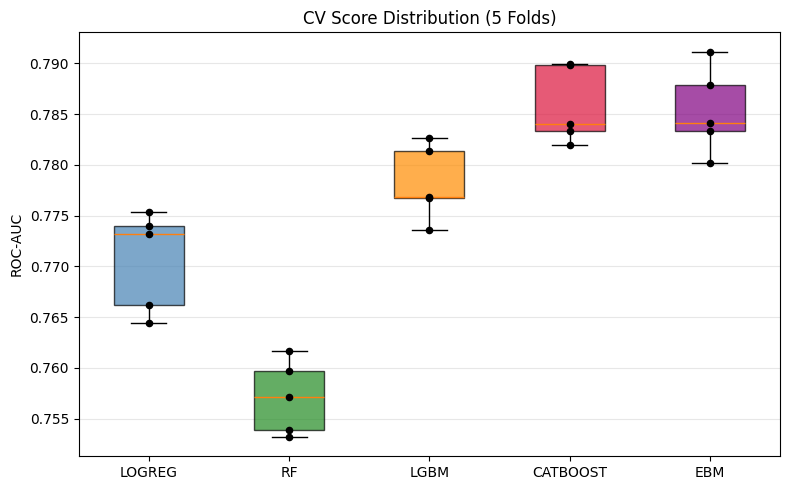

Saved → reports/cv_score_distribution.png


In [7]:
fig = plot_cv_score_distribution(
    results,
    save_path=ROOT / 'reports' / 'cv_score_distribution.png',
)
plt.show()
print('Saved → reports/cv_score_distribution.png')

## 5b. Precision-Recall Curves

PR-кривые особенно информативны при дисбалансе классов: они показывают trade-off между точностью и полнотой. Пунктирная линия — baseline (доля дефолтов ≈ 8%).

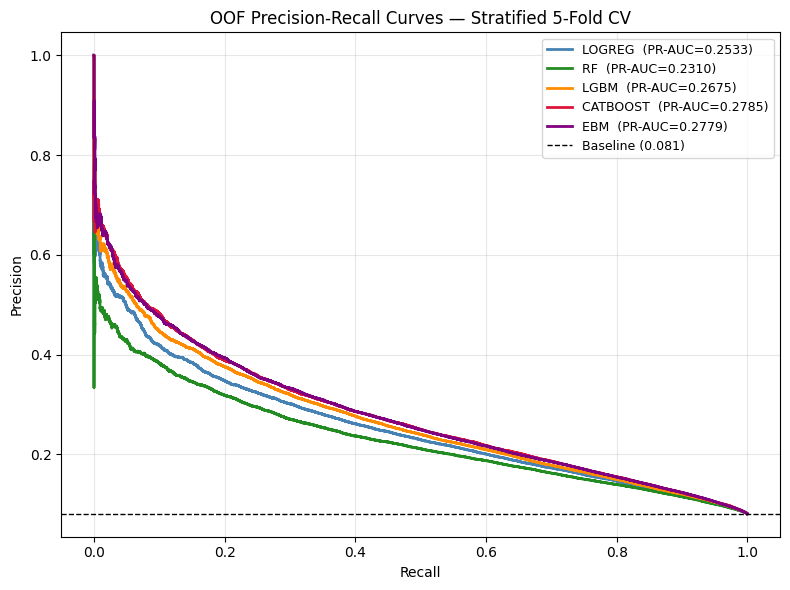

Saved → reports/pr_curves.png


In [8]:
fig = plot_pr_curves(
    results,
    save_path=ROOT / 'reports' / 'pr_curves.png',
)
plt.show()
print('Saved → reports/pr_curves.png')

## 5c. Grouped Bar Chart — All Metrics

Сравнительная диаграмма всех 6 метрик для каждой модели. Порог классификации = 0.5.  
> **Напоминание**: Accuracy намеренно завышена из-за дисбаланса классов — её следует читать вместе с Recall.

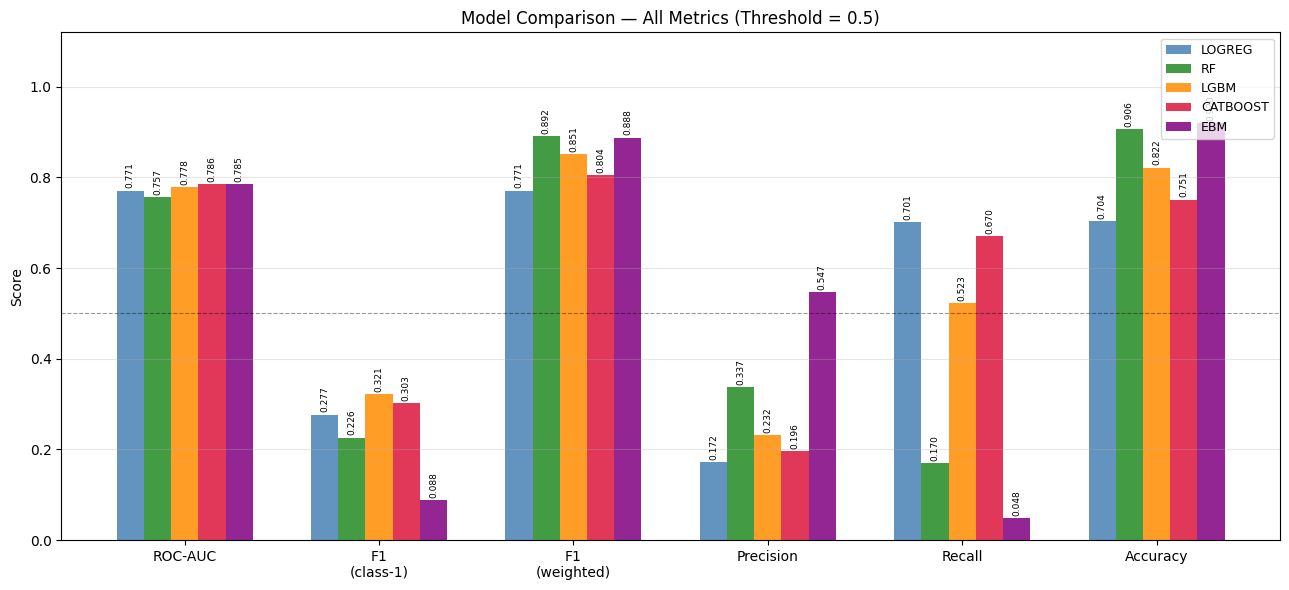

Saved → reports/metrics_comparison.png


In [9]:
fig = plot_metrics_comparison(
    results,
    save_path=ROOT / 'reports' / 'metrics_comparison.png',
)
plt.show()
print('Saved → reports/metrics_comparison.png')

## 5d. Per-Fold AUC Heatmap

Показывает стабильность модели по фолдам. Идеальная модель — одинаковые значения по строке. Правый столбец (μ) — среднее по фолдам.

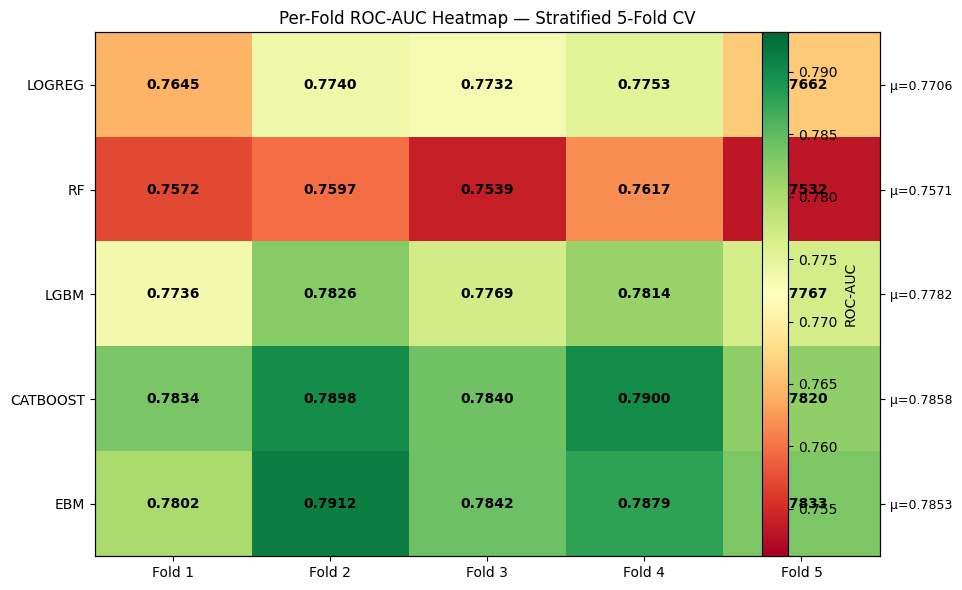

Saved → reports/fold_heatmap.png


In [10]:
fig = plot_fold_heatmap(
    results,
    save_path=ROOT / 'reports' / 'fold_heatmap.png',
)
plt.show()
print('Saved → reports/fold_heatmap.png')

## 5e. Radar Chart — Комплексный профиль моделей

Spider-диаграмма позволяет одним взглядом оценить сильные и слабые стороны каждой модели по всем метрикам одновременно. Большая площадь фигуры = более сильная модель в целом.

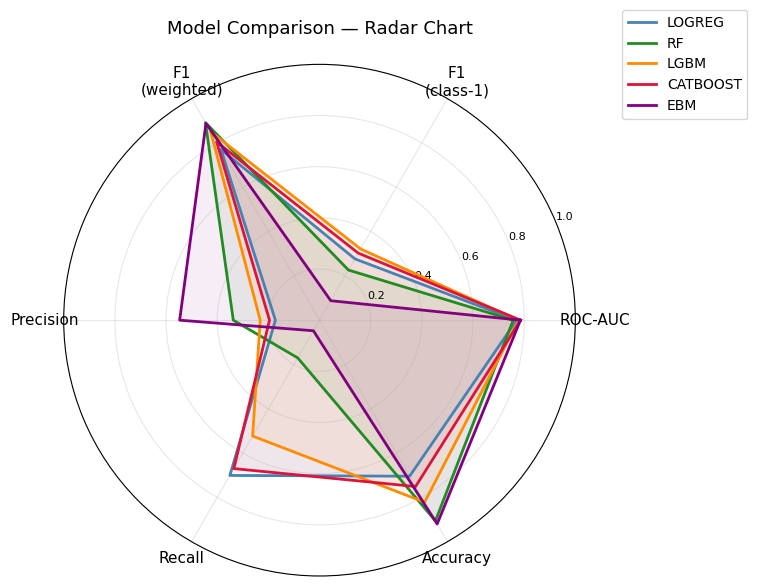

Saved → reports/metrics_radar.png


In [11]:
fig = plot_metrics_radar(
    results,
    save_path=ROOT / 'reports' / 'metrics_radar.png',
)
plt.show()
print('Saved → reports/metrics_radar.png')

## 7. Train Final Models on Full Data

CV gave us an honest AUC estimate. Now retrain each model on all 307,511 rows  
to get the strongest possible weights for inference.

In [12]:
final_models = {}

for name, model in models.items():
    print(f'Training final {name}...')
    final_models[name] = train_final_model(
        clone(model), X, y, model_name=name
    )
    save_model(final_models[name], name)

Training final logreg...
  Saved logreg → C:\Users\bekbo\Projects\final_boss\models\logreg.joblib  (7 KB)
Training final rf...
  Saved rf → C:\Users\bekbo\Projects\final_boss\models\rf.joblib  (915926 KB)
Training final lgbm...
  Saved lgbm → C:\Users\bekbo\Projects\final_boss\models\lgbm.joblib  (6795 KB)
Training final catboost...
  Saved catboost → C:\Users\bekbo\Projects\final_boss\models\catboost.joblib  (1114 KB)
Training final ebm...
  Saved ebm → C:\Users\bekbo\Projects\final_boss\models\ebm.joblib  (2885 KB)


## 8. Feature Importance — LightGBM

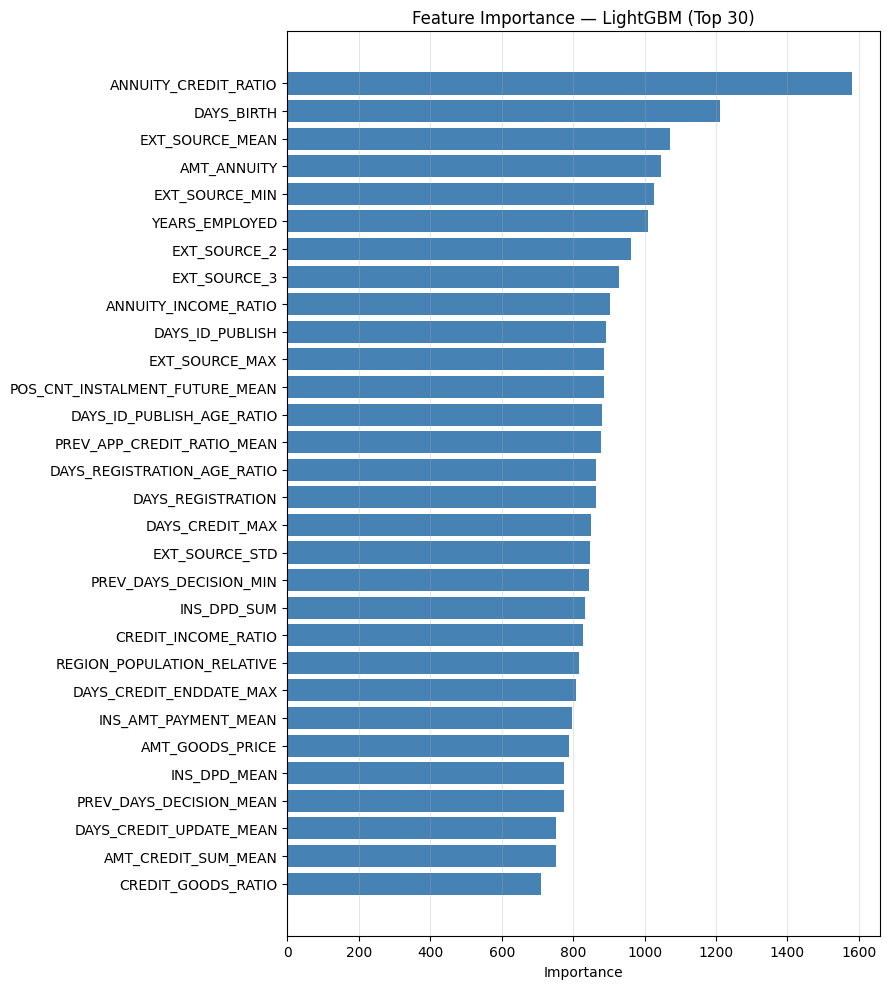

Saved → reports/feature_importance_lgbm.png


In [13]:
fig = plot_feature_importance(
    final_models['lgbm'],
    feature_names=X.columns.tolist(),
    top_n=30,
    model_name='LightGBM',
    save_path=ROOT / 'reports' / 'feature_importance_lgbm.png',
)
plt.show()
print('Saved → reports/feature_importance_lgbm.png')

## 9. Feature Importance — Random Forest

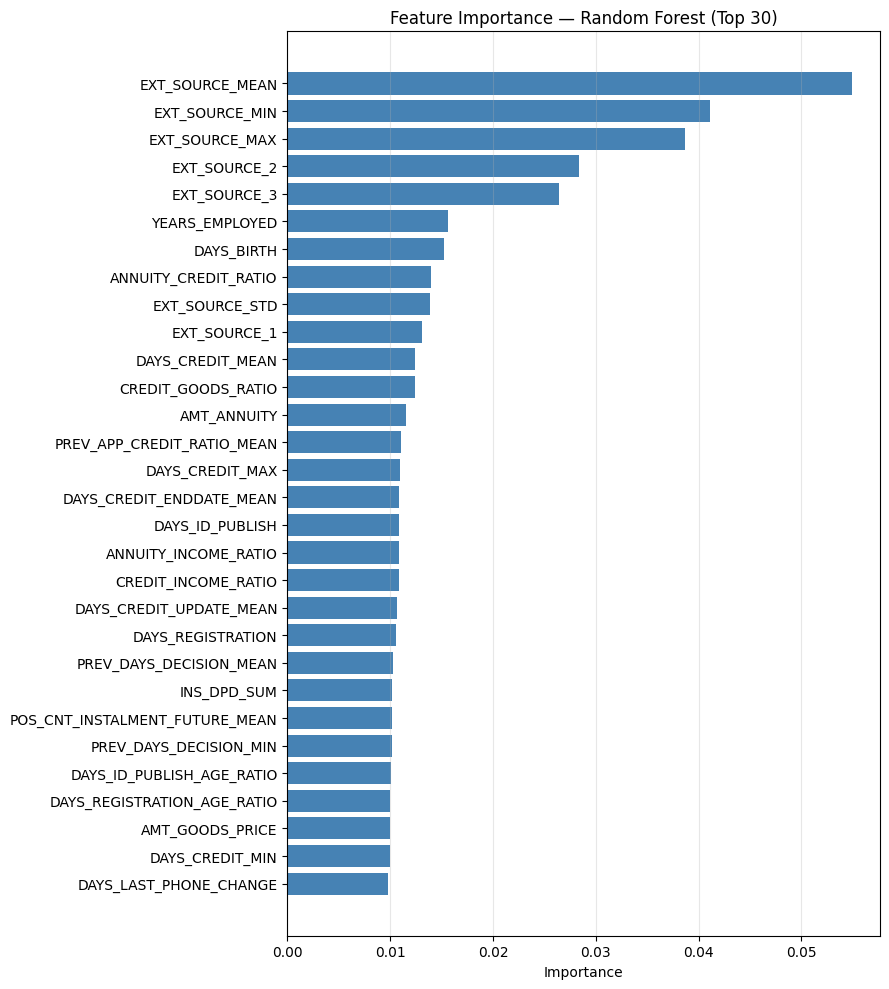

Saved → reports/feature_importance_rf.png


In [14]:
fig = plot_feature_importance(
    final_models['rf'],
    feature_names=X.columns.tolist(),
    top_n=30,
    model_name='Random Forest',
    save_path=ROOT / 'reports' / 'feature_importance_rf.png',
)
plt.show()
print('Saved → reports/feature_importance_rf.png')

## 10. Feature Importance — LogReg (Coefficients)

LogReg не имеет `feature_importances_`, используем абсолютные значения коэффициентов.  
Знак показывает направление влияния (красный = выше риск дефолта, синий = ниже).

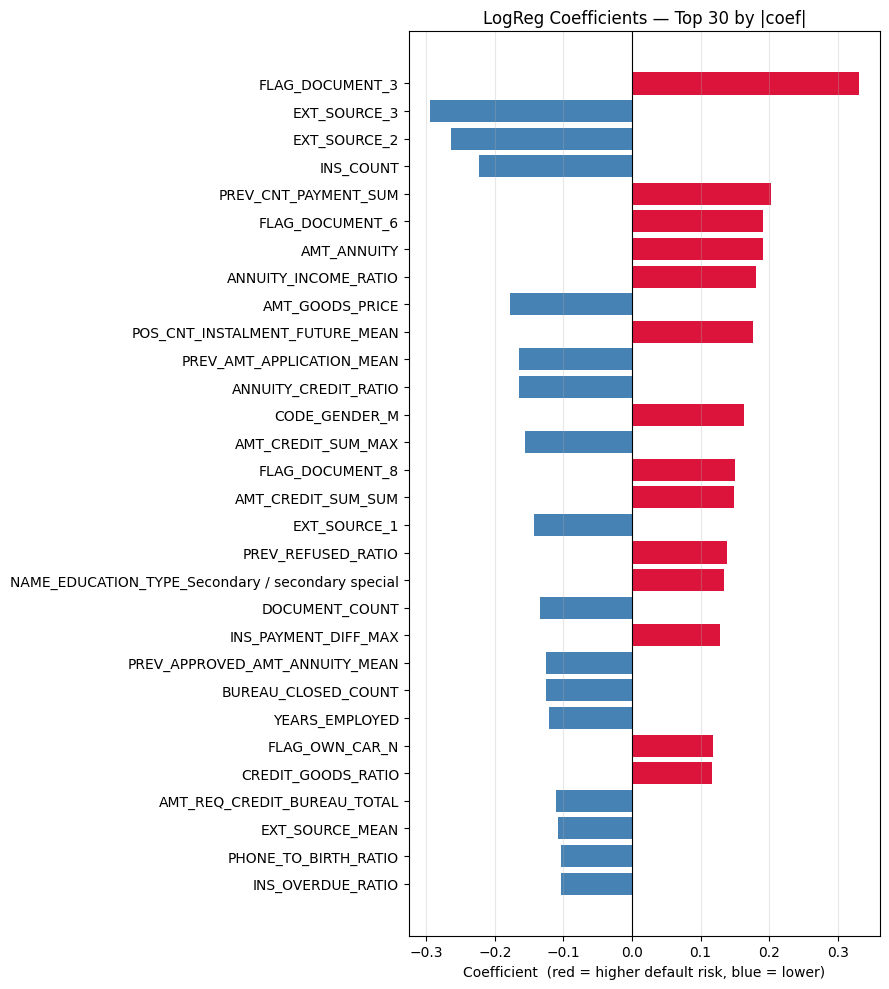

Saved → reports/feature_importance_logreg.png


In [15]:
coefs = final_models['logreg'].coef_[0]
feat_names = X.columns.tolist()

coef_df = (
    pd.DataFrame({'feature': feat_names, 'coef': coefs})
    .assign(abs_coef=lambda d: d['coef'].abs())
    .sort_values('abs_coef', ascending=False)
    .head(30)
)

colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['coef']]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient  (red = higher default risk, blue = lower)')
ax.set_title('LogReg Coefficients — Top 30 by |coef|')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(ROOT / 'reports' / 'feature_importance_logreg.png', dpi=150)
plt.show()
print('Saved → reports/feature_importance_logreg.png')

## 11. Feature Importance — CatBoost

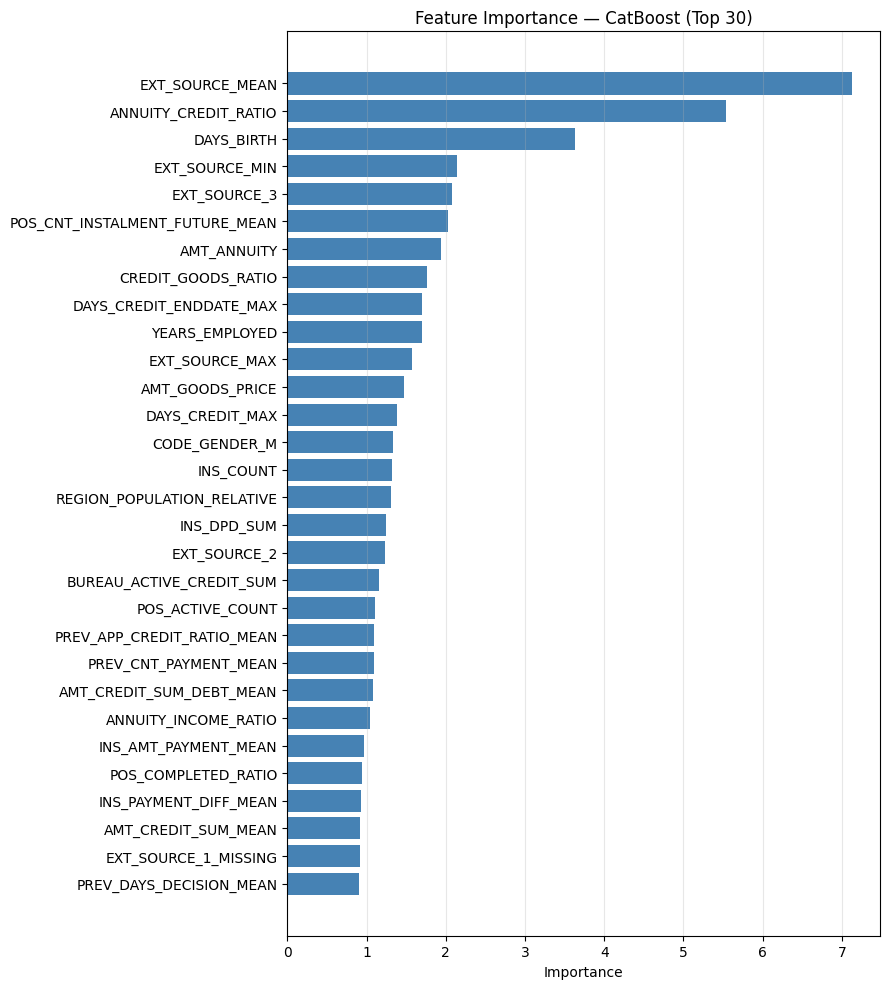

Saved → reports/feature_importance_catboost.png


In [16]:
fig = plot_feature_importance(
    final_models['catboost'],
    feature_names=X.columns.tolist(),
    top_n=30,
    model_name='CatBoost',
    save_path=ROOT / 'reports' / 'feature_importance_catboost.png',
)
plt.show()
print('Saved → reports/feature_importance_catboost.png')

## 12. SHAP Analysis — LightGBM

SHAP (SHapley Additive exPlanations) даёт честный вклад каждого признака в каждое предсказание.

- **Summary plot** — глобальная картина: какие признаки важны и в какую сторону
- **Bar plot** — mean |СHAП| как альтернативная мера важности
- Значения сохраняются в `models/lgbm_shap.joblib` для использования в notebook 05

> Используем subsample 5 000 строк для скорости (достаточно для глобальной картины)

SHAP values shape: (5000, 209)


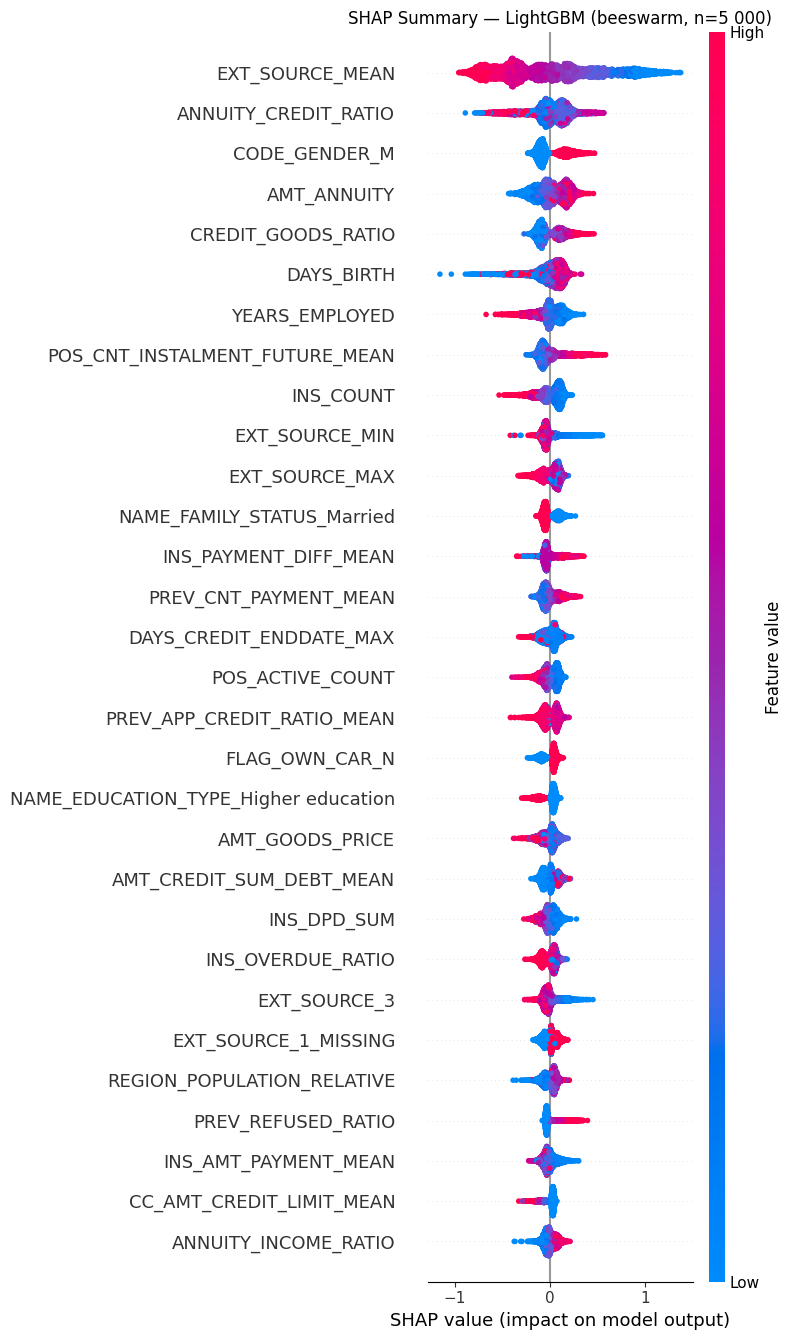

Saved → reports/shap_summary_lgbm.png


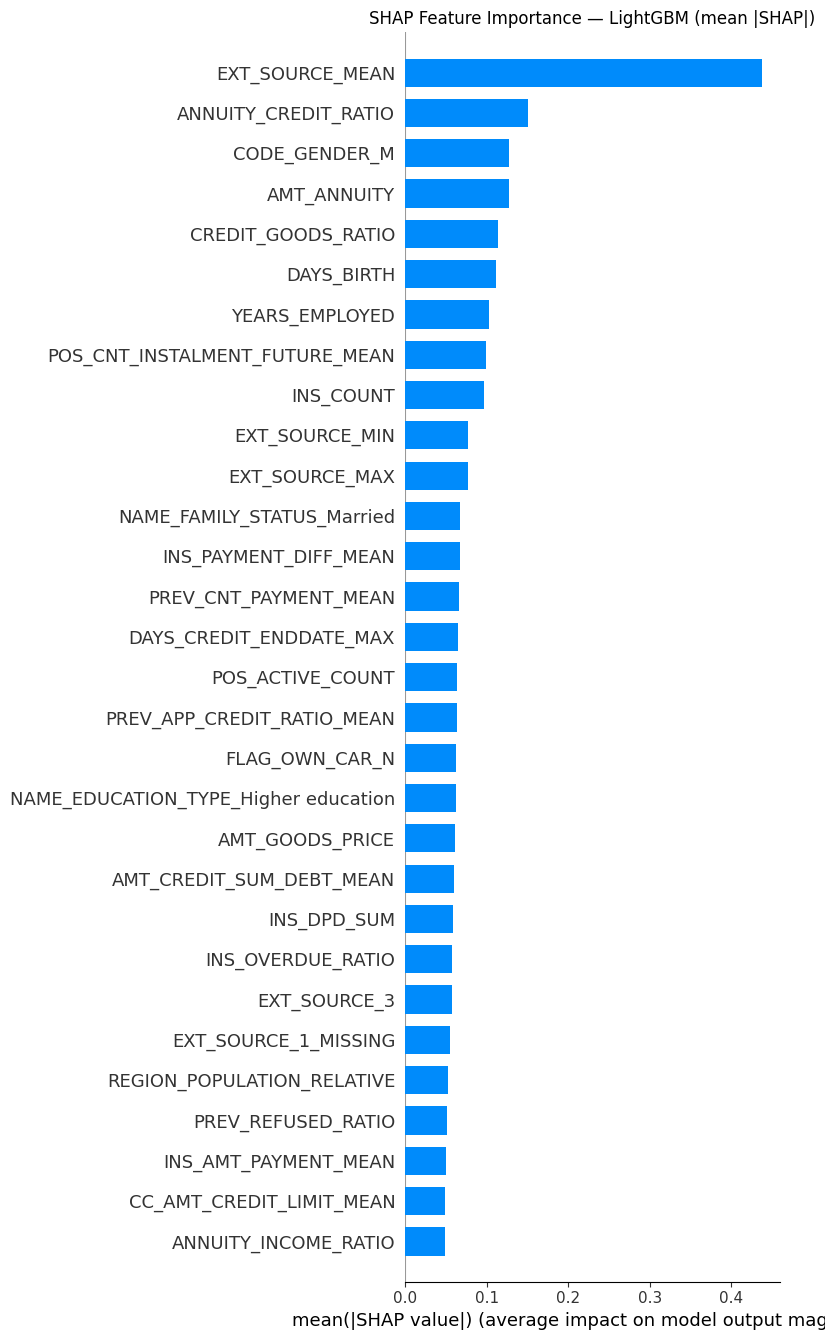

Saved → reports/shap_bar_lgbm.png
Saved → models/lgbm_shap.joblib


In [17]:
import warnings

rng = np.random.default_rng(config.RANDOM_SEED)
sample_idx = rng.choice(len(X), size=5000, replace=False)
X_shap = X.iloc[sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(final_models['lgbm'])

# shap_values() may return a list [neg_class, pos_class] in some SHAP versions,
# or a single 2D array (n_samples, n_features) in newer versions.
# We always extract the positive-class (default risk) array.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    _sv = explainer.shap_values(X_shap, check_additivity=False)

if isinstance(_sv, list):
    shap_values = _sv[1]   # positive class
elif hasattr(_sv, 'ndim') and _sv.ndim == 3:
    shap_values = _sv[:, :, 1]  # (n, features, 2) → positive class
else:
    shap_values = _sv  # already (n, features)

print(f'SHAP values shape: {shap_values.shape}')  # should be (5000, n_features)

# --- Summary plot (beeswarm) ---
shap.summary_plot(shap_values, X_shap, show=False, max_display=30)
plt.title('SHAP Summary — LightGBM (beeswarm, n=5 000)')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'shap_summary_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/shap_summary_lgbm.png')

# --- Bar plot (mean |SHAP|) ---
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=30)
plt.title('SHAP Feature Importance — LightGBM (mean |SHAP|)')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'shap_bar_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/shap_bar_lgbm.png')

# --- Persist для notebook 05 ---
shap_artifact = {'shap_values': shap_values, 'X_sample': X_shap, 'sample_idx': sample_idx}
joblib.dump(shap_artifact, config.MODELS_DIR / 'lgbm_shap.joblib')
print('Saved → models/lgbm_shap.joblib')

### 12.1 SHAP Dependence Plots — Top 3 признака

Показывают, как значение признака влияет на SHAP-вклад, с цветовым взаимодействием (авто-выбор).

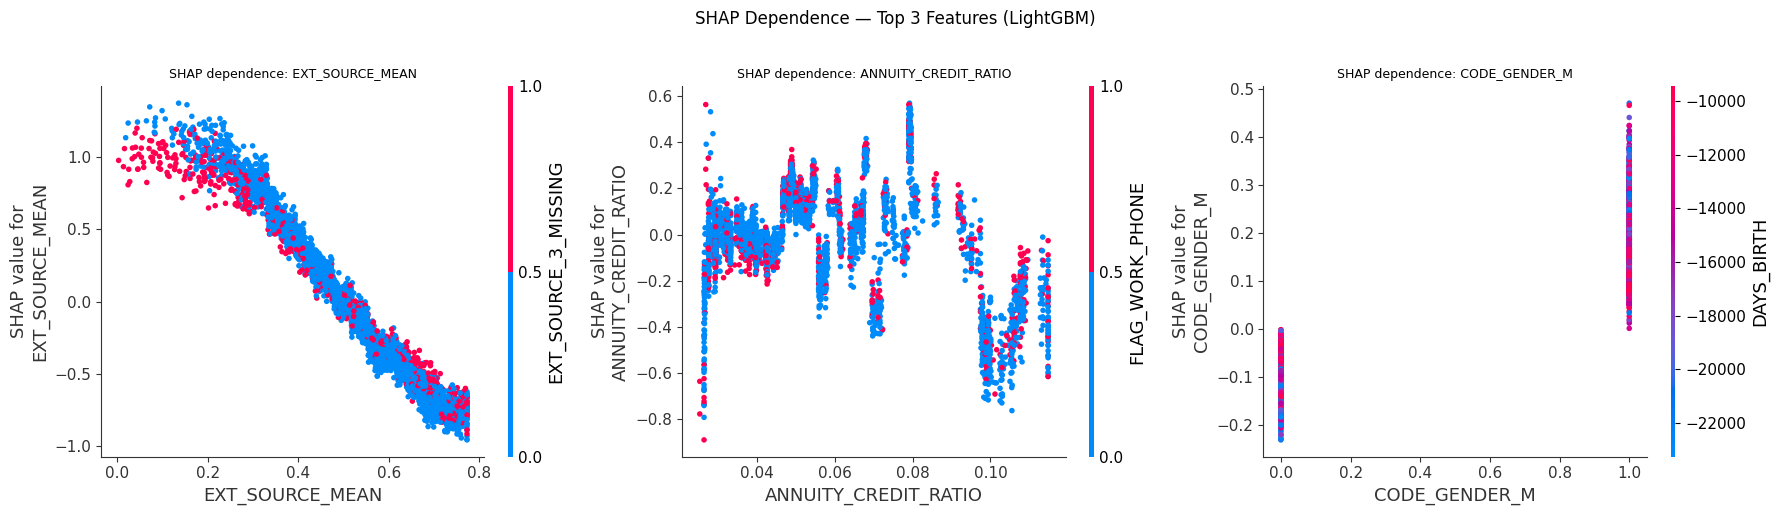

Saved → reports/shap_dependence_top3.png


In [18]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = [X_shap.columns[i] for i in top3_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_features):
    try:
        shap.dependence_plot(feat, shap_values, X_shap, ax=ax, show=False)
        ax.set_title(f'SHAP dependence: {feat}', fontsize=9)
    except Exception as e:
        ax.set_title(f'{feat}\n(plot unavailable: {e})', fontsize=8)
        ax.axis('off')

plt.suptitle('SHAP Dependence — Top 3 Features (LightGBM)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'shap_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/shap_dependence_top3.png')

## 13. EBM — Global Explanations

EBM (InterpretML) — единственная модель в наборе, которая **нативно интерпретируема**:  
каждая фича имеет форм-функцию `f_j(x_j)` + попарные взаимодействия.

- `explain_global()` — глобальные term importances и shape functions
- Важность каждого term сохраняется в CSV для notebook 05

> `show()` из interpret открывает интерактивный дашборд (работает в Jupyter Classic/Lab)

Top-20 EBM terms по важности:
        term  importance
feature_0109    0.195491
feature_0002    0.193863
feature_0023    0.168245
feature_0022    0.160864
feature_0056    0.157040
feature_0122    0.153506
feature_0003    0.141227
feature_0057    0.120887
feature_0139    0.119744
feature_0117    0.105483
feature_0052    0.103162
feature_0005    0.101541
feature_0055    0.090019
feature_0113    0.088079
feature_0206    0.085143
feature_0112    0.083485
feature_0140    0.081129
feature_0075    0.080398
feature_0098    0.064065
feature_0124    0.063967


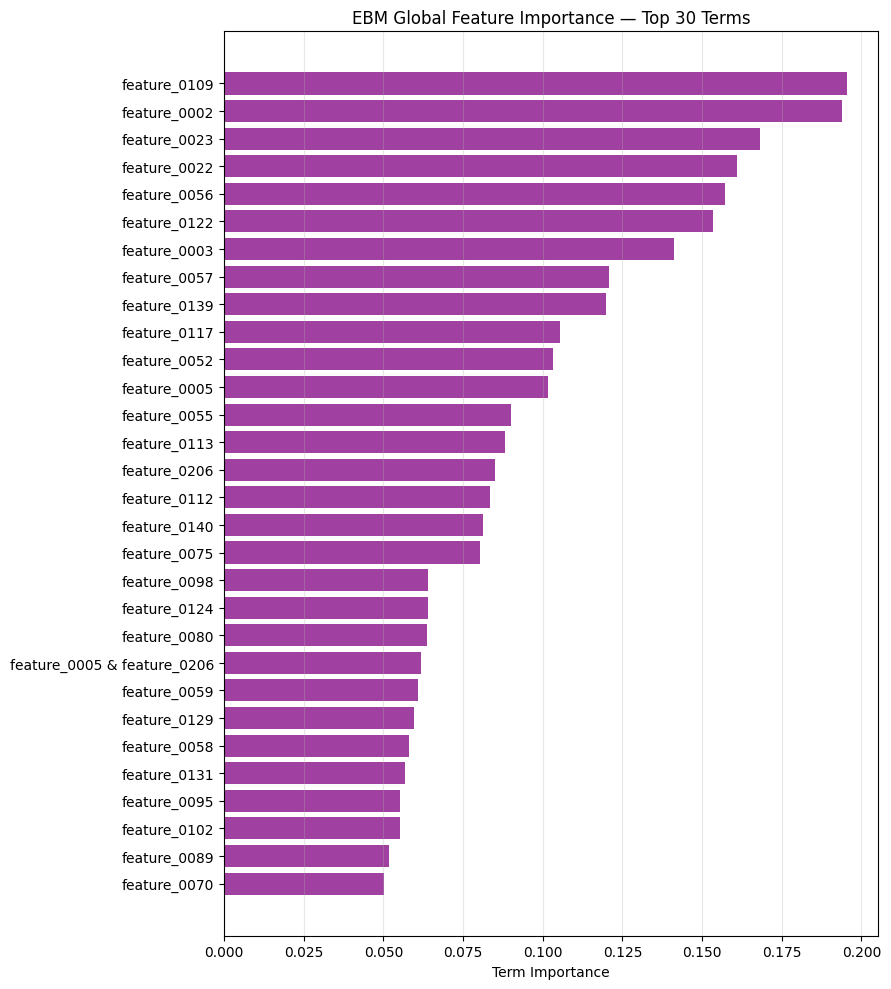

Saved → reports/feature_importance_ebm.png
Saved → reports/ebm_term_importances.csv


In [19]:
from interpret import show

ebm_global = final_models['ebm'].explain_global(name='EBM Global')

# Сохраняем term importances как DataFrame
ebm_importances = pd.DataFrame({
    'term': ebm_global.data()['names'],
    'importance': ebm_global.data()['scores'],
}).sort_values('importance', ascending=False)

print('Top-20 EBM terms по важности:')
print(ebm_importances.head(20).to_string(index=False))

# Bar chart top-30
top_ebm = ebm_importances.head(30)
fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(top_ebm['term'][::-1], top_ebm['importance'][::-1], color='purple', alpha=0.75)
ax.set_xlabel('Term Importance')
ax.set_title('EBM Global Feature Importance — Top 30 Terms')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(ROOT / 'reports' / 'feature_importance_ebm.png', dpi=150)
plt.show()
print('Saved → reports/feature_importance_ebm.png')

# Сохраняем для notebook 05
ebm_importances.to_csv(ROOT / 'reports' / 'ebm_term_importances.csv', index=False)
print('Saved → reports/ebm_term_importances.csv')

In [20]:
# Интерактивный дашборд (работает в Jupyter Classic/Lab; в VS Code может не открыться)
try:
    show(ebm_global)
except Exception as e:
    print(f'[INFO] Interactive EBM dashboard unavailable in this environment: {e}')
    print('Tip: run `jupyter lab` in terminal and open the notebook there for the full dashboard.')

<!-- http://127.0.0.1:7001/2956363304640/ -->

## 14. Model Loading Verification

In [21]:
loaded_lgbm = load_model('lgbm')
sample = X.head(5).to_numpy(dtype='float32')
preds = loaded_lgbm.predict_proba(sample)[:, 1]
print('Round-trip check — LightGBM predictions (first 5 rows):')
print(preds.round(4))

Round-trip check — LightGBM predictions (first 5 rows):
[0.9074 0.0753 0.1805 0.1575 0.3182]


## 15. Summary

In [22]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(comparison.to_string(index=False))

best = comparison.iloc[0]
print(f'\nBest model : {best["Model"]}')
print(f'ROC-AUC    : {best["ROC-AUC (mean)"]:.4f} ± {best["ROC-AUC (std)"]:.4f}')
print(f'F1 class-1 : {best["F1 class-1"]:.4f}')
print(f'Precision  : {best["Precision"]:.4f}')
print(f'Recall     : {best["Recall"]:.4f}')
print(f'Accuracy   : {best["Accuracy"]:.4f}')

print('\nSaved models:')
for name in final_models:
    p = config.MODELS_DIR / f'{name}.joblib'
    if p.exists():
        print(f'  {p.name:25s}  {p.stat().st_size / 1024:.0f} KB')

print('\nSaved artifacts:')
artifacts = [
    'reports/roc_curves.png',
    'reports/pr_curves.png',
    'reports/cv_score_distribution.png',
    'reports/metrics_comparison.png',
    'reports/fold_heatmap.png',
    'reports/metrics_radar.png',
    'reports/feature_importance_lgbm.png',
    'reports/feature_importance_rf.png',
    'reports/feature_importance_logreg.png',
    'reports/feature_importance_catboost.png',
    'reports/feature_importance_ebm.png',
    'reports/shap_summary_lgbm.png',
    'reports/shap_bar_lgbm.png',
    'reports/shap_dependence_top3.png',
    'reports/ebm_term_importances.csv',
    'models/lgbm_shap.joblib',
]
for a in artifacts:
    p = ROOT / a
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  [{status}] {a}')

print('\nNext step: 05_model_evaluation.ipynb')

FINAL SUMMARY
   Model  ROC-AUC (mean)  ROC-AUC (std)  F1 class-1  F1 weighted  Precision  Recall  Accuracy  AUC Fold 1  AUC Fold 2  AUC Fold 3  AUC Fold 4  AUC Fold 5
CATBOOST          0.7858         0.0034      0.3027       0.8043     0.1956  0.6699    0.7509      0.7834      0.7898      0.7840      0.7900      0.7820
     EBM          0.7853         0.0038      0.0879       0.8879     0.5467  0.0478    0.9199      0.7802      0.7912      0.7842      0.7879      0.7833
    LGBM          0.7782         0.0033      0.3213       0.8508     0.2319  0.5231    0.8216      0.7736      0.7826      0.7769      0.7814      0.7767
  LOGREG          0.7706         0.0044      0.2768       0.7708     0.1724  0.7008    0.7043      0.7645      0.7740      0.7732      0.7753      0.7662
      RF          0.7571         0.0033      0.2263       0.8915     0.3370  0.1703    0.9060      0.7572      0.7597      0.7539      0.7617      0.7532

Best model : CATBOOST
ROC-AUC    : 0.7858 ± 0.0034
F1 class-1